В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any


def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [2]:
raw_df = pd.read_csv('train.csv', index_col=0)
raw_df.head(5)

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,,,,,,,,,,,,,
0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [3]:
target_col = 'Exited'
input_cols = list(raw_df.columns)[2:-1]

train_df, val_df = split_train_val(raw_df, target_col)
train_inputs, train_targets = separate_inputs_targets(train_df, input_cols, target_col)
val_inputs, val_targets = separate_inputs_targets(val_df, input_cols, target_col)

1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [4]:
cat_cols = train_inputs.select_dtypes('object').columns

train_inputs[cat_cols] = train_inputs[cat_cols].astype('category')
val_inputs[cat_cols] = val_inputs[cat_cols].astype('category')

2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [5]:
from xgboost import XGBClassifier

In [25]:
# не вдалось реалізувати через конфлікт бібліотек
# import cudf
# train_inputs_cuda = cudf.DataFrame(train_inputs)
# val_inputs_cuda = cudf.DataFrame(val_inputs)

In [6]:
xgb_clf = XGBClassifier(
    n_estimators = 50,
    max_depth = 3,
    enable_categorical = True,
    missing = np.nan,
    device = 'cuda',
    random_state=42
)

xgb_clf.fit(train_inputs, train_targets)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, ...)

In [7]:
from sklearn.metrics import roc_auc_score

def compute_auroc(inputs, targets, model, name=''):
  y_pred_proba = model.predict_proba(inputs)[:, 1]
  roc_auc = roc_auc_score(targets, y_pred_proba)

  print(f'AUROC for {name}: {roc_auc:.4f}')
  return roc_auc

In [8]:
compute_auroc(train_inputs, train_targets, xgb_clf, 'train')
compute_auroc(val_inputs, val_targets, xgb_clf, 'val');

AUROC for train: 0.9464
AUROC for val: 0.9360


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [17:28:14] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


**Спостереження:**
- натренована модель гарно перфомить, не є перенавченою.
- схожі результати в мене вже були для LogisticRegression з PolynomialFeatures, але треба перевіряти на фінальному тестовому наборі.

3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [9]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval

In [10]:
def objective(space):
  clf = XGBClassifier(early_stopping_rounds=10,
                        **space)
  clf.fit(train_inputs,
          train_targets,
          eval_set=[(val_inputs, val_targets)],
          verbose=False
  )

  auroc = compute_auroc(val_inputs, val_targets, clf, 'val')
  return {'loss': -auroc, 'status': STATUS_OK}

# параметри
space = {
    'n_estimators':     hp.choice("n_estimators", np.arange(50, 500, 25, dtype='int')),
    'max_depth':        hp.choice('max_depth', np.arange(2, 20, 1, dtype=int)),
    'learning_rate':    hp.uniform('learning_rate', 0.01, 1),
    'min_child_weight': hp.choice('min_child_weight', np.arange(1, 50, 1, dtype=int)),
    'subsample':        hp.uniform('subsample', 0.5, 1.),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.),
    'gamma':            hp.uniform('gamma', 0, 10),
    'reg_alpha':        hp.uniform('reg_alpha', 0, 1),
    'reg_lambda':       hp.uniform('reg_lambda', 0, 1),
    'random_state':     42,
    'missing':          np.nan,
    'enable_categorical': True,
    'device':           'cuda',
    'eval_metric':      'auc',
    'grow_policy':      'lossguide',
}

trials = Trials()
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=20,
            trials=trials)

print("Найкращі гіперпараметри: ", best)

AUROC for val: 0.9343
AUROC for val: 0.9303
AUROC for val: 0.9112
AUROC for val: 0.9283
AUROC for val: 0.9115
AUROC for val: 0.9348
AUROC for val: 0.9101
AUROC for val: 0.9348
AUROC for val: 0.9299
AUROC for val: 0.9365
AUROC for val: 0.9178
AUROC for val: 0.9276
AUROC for val: 0.9353
AUROC for val: 0.9361
AUROC for val: 0.9369
AUROC for val: 0.9356
AUROC for val: 0.9128
AUROC for val: 0.9078
AUROC for val: 0.9039
AUROC for val: 0.9316
100%|██████████| 20/20 [00:02<00:00,  8.25trial/s, best loss: -0.9369233143562659]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.6765380760487965), 'gamma': np.float64(7.5607136344793755), 'learning_rate': np.float64(0.1130950019226815), 'max_depth': np.int64(11), 'min_child_weight': np.int64(18), 'n_estimators': np.int64(16), 'reg_alpha': np.float64(0.31798881154302894), 'reg_lambda': np.float64(0.29421293159137785), 'subsample': np.float64(0.9875669462532322)}


In [11]:
best_params = space_eval(space, best)
best_params

{'colsample_bytree': 0.6765380760487965,
 'device': 'cuda',
 'enable_categorical': True,
 'eval_metric': 'auc',
 'gamma': 7.5607136344793755,
 'grow_policy': 'lossguide',
 'learning_rate': 0.1130950019226815,
 'max_depth': np.int64(13),
 'min_child_weight': np.int64(19),
 'missing': nan,
 'n_estimators': np.int64(450),
 'random_state': 42,
 'reg_alpha': 0.31798881154302894,
 'reg_lambda': 0.29421293159137785,
 'subsample': 0.9875669462532322}

In [12]:
final_clf = XGBClassifier(**best_params)
final_clf.fit(train_inputs, train_targets)

compute_auroc(train_inputs, train_targets, final_clf, 'train')
compute_auroc(val_inputs, val_targets, final_clf, 'val');

AUROC for train: 0.9396
AUROC for val: 0.9368


**Спостереження**
- нова модель дала схожі результати з попередньою
- auroc на валідаційному наборі кращий на 0,0008 (0.9368 vs 0.9360)


4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [13]:
import lightgbm as lgb

In [14]:
cat_features_idx = [train_inputs.columns.get_loc(col) for col in cat_cols]

In [15]:
lgb_clf = lgb.LGBMClassifier(
    max_depth=3,
    n_estimators=50,
    learning_rate=0.1,
    random_state=42
)

lgb_clf.fit(train_inputs,
            train_targets,
            eval_set=[(val_inputs, val_targets)],
            eval_metric='auc',
            categorical_feature=cat_features_idx
)

[LightGBM] [Info] Number of positive: 2442, number of negative: 9558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001033 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 843
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203500 -> initscore=-1.364561
[LightGBM] [Info] Start training from score -1.364561
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

LGBMClassifier(max_depth=3, n_estimators=50, random_state=42)

In [16]:
compute_auroc(train_inputs, train_targets, lgb_clf, 'train')
compute_auroc(val_inputs, val_targets, lgb_clf, 'val');

AUROC for train: 0.9388
AUROC for val: 0.9362


**Спостереження**
- модель LGBMClassifier краще перфомить, auroc на трейн та валідаційному наборах даних відрізняються на 0.0024

5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

In [21]:
def objective(space):
  clf = lgb.LGBMClassifier(early_stopping_rounds=10,
                        **space)
  clf.fit(train_inputs,
          train_targets,
          eval_set=[(val_inputs, val_targets)],
          categorical_feature=cat_features_idx
  )

  auroc = compute_auroc(val_inputs, val_targets, clf, 'val')
  return {'loss': -auroc, 'status': STATUS_OK}

# параметри
space = {
    'n_estimators':     hp.choice("n_estimators", np.arange(50, 500, 25, dtype='int')),
    'max_depth':        hp.choice('max_depth', np.arange(2, 20, 1, dtype=int)),
    'num_leaves':       hp.choice('num_leaves', np.arange(20, 150, 1, dtype=int)),
    'learning_rate':    hp.uniform('learning_rate', 0.01, 0.3),
    'subsample':        hp.uniform('subsample', 0.5, 1.),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.),
    'min_split_gain':   hp.uniform('min_split_gain', 0, 0.1),
    'min_child_weight': hp.choice('min_child_weight', np.arange(1, 50, 1, dtype=int)),
    'reg_alpha':        hp.uniform('reg_alpha', 0, 1),
    'reg_lambda':       hp.uniform('reg_lambda', 0, 1),
    'random_state':     42,
    'metric':           'auc',
    'subsample_freq':   1,
    'verbose':          -1
}

trials = Trials()
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=10,
            trials=trials)

print("Найкращі гіперпараметри: ", best)

AUROC for val: 0.9353
AUROC for val: 0.9334
AUROC for val: 0.9360
AUROC for val: 0.9343
AUROC for val: 0.9360
AUROC for val: 0.9326
AUROC for val: 0.9376
AUROC for val: 0.9216
AUROC for val: 0.9347
AUROC for val: 0.9359
100%|██████████| 10/10 [00:01<00:00,  7.36trial/s, best loss: -0.9376431854036628]
Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.8086019294274172), 'learning_rate': np.float64(0.1362770358739998), 'max_depth': np.int64(1), 'min_child_weight': np.int64(3), 'min_split_gain': np.float64(0.09853171403832309), 'n_estimators': np.int64(9), 'num_leaves': np.int64(29), 'reg_alpha': np.float64(0.3464817447241404), 'reg_lambda': np.float64(0.29741513125279684), 'subsample': np.float64(0.8736545722774365)}


In [22]:
best_params = space_eval(space, best)

final_lgb_clf = lgb.LGBMClassifier(**best_params)
final_lgb_clf.fit(train_inputs, train_targets)

compute_auroc(train_inputs, train_targets, final_lgb_clf, 'train')
compute_auroc(val_inputs, val_targets, final_lgb_clf, 'val');

AUROC for train: 0.9565
AUROC for val: 0.9337


**Спостереження**: модель перенавчена

6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

In [26]:
test_df = pd.read_csv('test.csv')
submission = pd.read_csv('sample_submission.csv')

test_inputs = test_df[input_cols].copy()
test_inputs[cat_cols] = test_inputs[cat_cols].astype('category')

test_preds_proba = lgb_clf.predict_proba(test_inputs)[:, 1]

submission['Exited'] = test_preds_proba

submission.to_csv('submission_lgb_clf.csv', index=False)

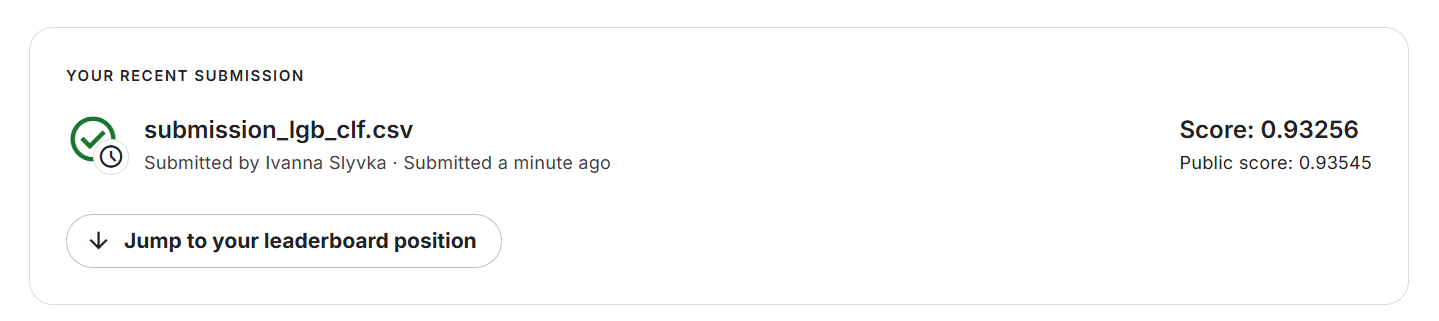